In [12]:
from typing import Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

load_dotenv()

True

In [16]:
llm = ChatOpenAI(model="qwen-plus", temperature=0)


class AgentState(BaseModel):
    messages: Annotated[list[BaseMessage], add_messages] = Field(default_factory=list)
    candidate_title: str = ""
    is_valid: bool = False
    attempts: int = 0


extractor_system_msg = SystemMessage('''# Role
你是一个专业的文档元数据提取助手，专门负责从报告文本中识别并提取报告的正式名称。

# Task
我会为你提供一份报告的前两页内容。请你仔细阅读，并找出该报告的官方标题/名称。

# Constraints (必须严格遵守)
1. 输出要求：只输出提取到的报告名称，严禁包含任何解释、前缀（如“标题是：”）、后缀或标点符号。
2. 准确性：必须从原文中提取，不要进行总结或改写。
3. 纯净度：如果报告名称中包含版本号（如 v1.0）或日期且属于标题的一部分，请一并保留。
4. 兜底处理：如果无法在文本中明确识别出报告名称，请只输出“无法识别”，不要尝试猜测。''')

extractor_prompt = ChatPromptTemplate.from_messages([
    extractor_system_msg,
    MessagesPlaceholder(variable_name="messages"),
])

auditor_system_msg = SystemMessage('''你是一个严格的数据质量审计员。你的任务是检查提取出的“报告名称”是否完全纯净。

检查标准：
1. 只能包含报告名称本身。
2. 严禁包含任何前缀（如“标题是：”、“提取的名称：”）、后缀、解释性文字。
3. 严禁包含 Markdown 格式（如加粗 **）或不必要的引号（"" 或 《》）。

如果完全符合标准，请只输出 "PASS"（大写，不要有其他字符）。
如果不符合标准，请明确指出多余的部分，并严厉要求对方重新输出纯净的名称。''')

auditor_prompt = ChatPromptTemplate.from_messages([
    auditor_system_msg,
    ("human", "待审核的标题候选：\n{candidate_title}")
])

extractor_chain = extractor_prompt | llm
auditor_chain = auditor_prompt | llm


def extract_node(state: AgentState):
    """提取者节点：负责生成标题"""
    attempts = state.attempts + 1

    response = extractor_chain.invoke({"messages": state.messages})
    candidate_title = response.content.strip()

    return {
        "messages": [response],
        "candidate_title": candidate_title,
        "attempts": attempts
    }


def audit_node(state: AgentState):
    """审计者节点：负责校验标题"""
    candidate_title = state.candidate_title
    audit_response = auditor_chain.invoke({"candidate_title": candidate_title})
    audit_feedback = audit_response.content.strip()

    if audit_feedback.startswith("PASS"):
        return {"is_valid": True}
    else:
        feedback_msg = AIMessage(
            name='Auditor',
            content=f"你的输出未通过审核。审计员的反馈是：\n{audit_feedback}\n请根据反馈修正，记住：只能输出纯净的报告名称！"
        )
        return {"is_valid": False, "messages": [feedback_msg], "test": 1}


def should_continue(state: AgentState):
    """路由判断：决定是结束还是继续重试"""
    if state.is_valid:
        return END
    if state.attempts >= 3:  # 设定最大重试次数为 3
        return END
    return "extractor"


builder = StateGraph(AgentState)

builder.add_node("extractor", extract_node)
builder.add_node("auditor", audit_node)

builder.add_edge(START, "extractor")
builder.add_edge("extractor", "auditor")
builder.add_conditional_edges("auditor", should_continue, {
    "extractor": "extractor",
    END: END
})

# 编译工作流
workflow = builder.compile()

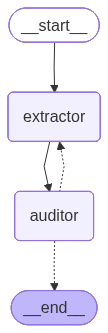

In [17]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

In [24]:
sample_report_text = """
摘 要: 研究聚焦于油气储运管道泄漏对地下水污染的深度分析。在污染区沿地下水流向垂直方向设置 10 个  观测井,在 10 个观测井的不同深度分别采集水样。石油类污染物的水质分析指标包括总油浓度、苯系物、长链  烃、氯化钠,天然气污染物的水质分析指标包括溶解氧、硫化物、挥发性有机物,分别采用不同方法实施含量测  定。结果表明,油气泄漏严重污染地下水,包气带污染更甚。苯系物与硫化物污染呈扩散态势,以泄漏点为中  心向地下水流动方向递减。并强调,油气管道泄漏对地下水环境的污染影响重大,需采取有效措施加以防控,  确保环境安全。  关键词: 观测井; 油气储运管道泄漏; 地下水环境污染; 苯系物  中图分类号: X523 文献标志码: ey words: observation well; leakage of oil and gas storage and transportation pipelines; groundwater environmental pollution; benzene derivatives  前言  油气储运管道作为关键能源设施,其安全备受  瞩目。然而,由于管道老化、腐蚀、施工缺陷及自然  灾害常导致油气储运管道泄漏,不仅浪费资源,更对  地下水构成 严 重 污 染 风 险[1]。 地 下 水 作 为 宝 贵 淡  水资源,关乎人类生存与生态健康。油气泄漏后,污  染物可渗透土壤、经地表径流污染地下水,威胁水质  与公众健康[2]。因此,探讨油气管道泄漏对地下水  污染的机制、特征及防控策略,具有重大理论与实
"""

result = workflow.invoke(input={"messages": [HumanMessage(sample_report_text)]})

for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================


摘 要: 研究聚焦于油气储运管道泄漏对地下水污染的深度分析。在污染区沿地下水流向垂直方向设置 10 个  观测井,在 10 个观测井的不同深度分别采集水样。石油类污染物的水质分析指标包括总油浓度、苯系物、长链  烃、氯化钠,天然气污染物的水质分析指标包括溶解氧、硫化物、挥发性有机物,分别采用不同方法实施含量测  定。结果表明,油气泄漏严重污染地下水,包气带污染更甚。苯系物与硫化物污染呈扩散态势,以泄漏点为中  心向地下水流动方向递减。并强调,油气管道泄漏对地下水环境的污染影响重大,需采取有效措施加以防控,  确保环境安全。  关键词: 观测井; 油气储运管道泄漏; 地下水环境污染; 苯系物  中图分类号: X523 文献标志码: ey words: observation well; leakage of oil and gas storage and transportation pipelines; groundwater environmental pollution; benzene derivatives  前言  油气储运管道作为关键能源设施,其安全备受  瞩目。然而,由于管道老化、腐蚀、施工缺陷及自然  灾害常导致油气储运管道泄漏,不仅浪费资源,更对  地下水构成 严 重 污 染 风 险[1]。 地 下 水 作 为 宝 贵 淡  水资源,关乎人类生存与生态健康。油气泄漏后,污  染物可渗透土壤、经地表径流污染地下水,威胁水质  与公众健康[2]。因此,探讨油气管道泄漏对地下水  污染的机制、特征及防控策略,具有重大理论与实

================================== Ai Message ==================================

无法识别
================================== Ai Message ==================================
Name: Auditor

你的输出未通过审核。审计员的反馈是：
无法识别
请根据反馈修正，记住：只能输出纯净的报告名称！
=====